# Modèle classique - Régression Logistique avec TF-IDF

Baseline pour la classification de sentiment sur Sentiment140.

**Approche :** Pipeline TF-IDF + Régression Logistique, hyperparamètres réglés via GridSearchCV.  
**Suivi des expériences :** MLFlow.  
**Objectif :** établir une performance de référence avant les modèles deep learning.

## 1. Configuration de l'environnement

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

print("Imports effectués avec succès.")

Imports effectues avec succes.


## 2. Configuration de MLFlow

In [2]:
import mlflow

mlflow.set_tracking_uri("sqlite:///D:/code/Projet7/notebooks/mlflow.db")
mlflow.set_experiment("classique")

print(f"Experience MLFlow : {mlflow.get_experiment_by_name('classique')}")

2026/05/07 21:54:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/07 21:54:28 INFO mlflow.store.db.utils: Updating database tables
2026/05/07 21:54:48 INFO mlflow.tracking.fluent: Experiment with name 'classique' does not exist. Creating a new experiment.


Experience MLFlow : <Experiment: artifact_location='file:///d:/code/Projet7/notebooks/mlruns/1', creation_time=1778183688848, experiment_id='1', last_update_time=1778183688848, lifecycle_stage='active', name='classique', tags={}, trace_location=None, workspace='default'>


## 3. Chargement des données preprocessées

`train.csv`, `val.csv` et `test.csv` ont été produits par `01_exploration.ipynb` et sauvegardés dans `data/`.  
Colonnes :
- `text_clean` : texte du tweet après preprocessing (nettoyage, lemmatisation, stopwords)
- `target` : étiquette binaire (0 = négatif, 1 = positif)

In [3]:
DATA_DIR = os.path.join(os.path.abspath(".."), "data")

df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
df_val   = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

X_train = df_train["text_clean"].fillna("").astype(str)
y_train = df_train["target"].astype(int)

X_val = df_val["text_clean"].fillna("").astype(str)
y_val = df_val["target"].astype(int)

X_test = df_test["text_clean"].fillna("").astype(str)
y_test = df_test["target"].astype(int)

print(f"Taille train      : {len(X_train):>10,} exemples")
print(f"Taille validation : {len(X_val):>10,} exemples")
print(f"Taille test       : {len(X_test):>10,} exemples")
print()
print("Distribution des classes (train) :")
print(y_train.value_counts().rename({0: "Négatif (0)", 1: "Positif (1)"}))

Taille train      :  1,273,984 exemples
Taille validation :    159,248 exemples
Taille test       :    159,249 exemples

Distribution des classes (train) :
target
Negatif (0)    637132
Positif (1)    636852
Name: count, dtype: int64


## 4. Pipeline TF-IDF + Régression Logistique

### Choix

- **TF-IDF n-grammes (1,2)** : capte unigrams et bigrams, ce qui préserve des expressions comme "not good".
- **Régression Logistique (liblinear)** : rapide et efficace en grande dimension, adapté aux matrices creuses TF-IDF.
- **GridSearchCV (cv=3)** : recherche exhaustive avec validation croisée 3 plis. Métrique cible : F1.

### Grille d'hyperparamètres

| Paramètre              | Valeurs testées         |
|------------------------|-------------------------|
| `tfidf__max_features`  | 30 000, 50 000, 100 000 |
| `clf__C`               | 0.1, 1, 10              |

9 combinaisons x 3 plis = 27 ajustements.

In [4]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LogisticRegression(solver="liblinear", max_iter=1000)),
])

param_grid = {
    "tfidf__max_features": [30000, 50000, 100000],
    "clf__C": [0.1, 1, 10],
}

with mlflow.start_run(run_name="logistic_regression"):
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=3,
        scoring="f1",
        n_jobs=-1,
        verbose=1,
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    mlflow.log_params(grid.best_params_)

    mlflow.log_metric("accuracy",  accuracy_score(y_test, y_pred))
    mlflow.log_metric("f1_score",  f1_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("recall",    recall_score(y_test, y_pred))

    fig, ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
    ax.set_title("Matrice de confusion - Régression Logistique")
    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.close(fig)

    mlflow.sklearn.log_model(best_model, "model")

    run_id = mlflow.active_run().info.run_id
    mlflow.register_model(f"runs:/{run_id}/model", "logistic_regression")

    print(f"Run ID : {run_id}")
    print(f"Meilleurs paramètres : {grid.best_params_}")
    print(f"Meilleur score CV (F1) : {grid.best_score_:.4f}")

2026/05/07 21:54:53 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Fitting 3 folds for each of 9 candidates, totalling 27 fits


2026/05/07 22:00:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 22:00:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'logistic_regression'.
2026/05/07 22:01:45 WARNING mlflow.tracking._model_registry.fluent: Run with id 13497675e2e84b6ab2fd0000998e99c6 has no artifacts at artifact path 'model', registering model based on models:/m-6ae6287c04274c129ceb4b2994f02632 instead
Created version '1' of model 'logistic_regression'.


Run ID : 13497675e2e84b6ab2fd0000998e99c6
Meilleurs parametres : {'clf__C': 1, 'tfidf__max_features': 100000}
Meilleur score CV (F1) : 0.7987


## 5. Évaluation du modèle

### Résultats sur le jeu de test

Rapport de classification détaillé et matrice de confusion. Le jeu de test n'a jamais servi à l'entraînement ni à la validation croisée.

In [5]:
print("=" * 55)
print("Rapport de classification - Régression Logistique")
print("=" * 55)
print(classification_report(
    y_test,
    y_pred,
    target_names=["Négatif (0)", "Positif (1)"],
))

print("-" * 55)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred):.4f}")
print(f"Précision : {precision_score(y_test, y_pred):.4f}")
print(f"Rappel    : {recall_score(y_test, y_pred):.4f}")

Rapport de classification - Regression Logistique
              precision    recall  f1-score   support

 Negatif (0)       0.81      0.78      0.79     79642
 Positif (1)       0.79      0.81      0.80     79607

    accuracy                           0.80    159249
   macro avg       0.80      0.80      0.80    159249
weighted avg       0.80      0.80      0.80    159249

-------------------------------------------------------
Accuracy  : 0.7972
F1-score  : 0.8002
Precision : 0.7882
Rappel    : 0.8127


### Matrice de confusion

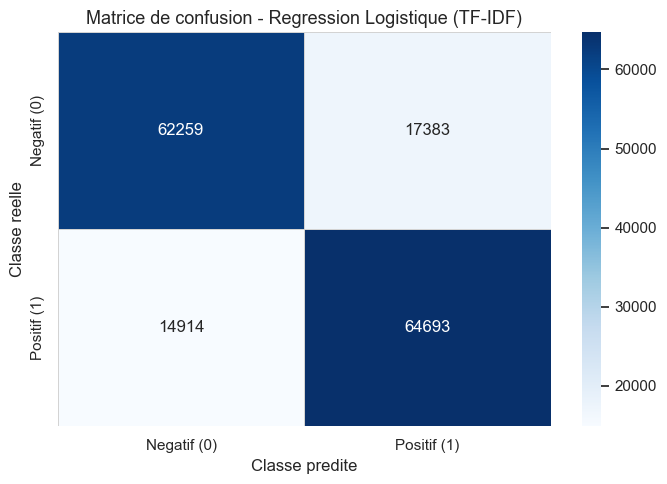

In [6]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Négatif (0)", "Positif (1)"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
    linewidths=0.5,
    linecolor="lightgrey",
)
ax.set_xlabel("Classe prédite", fontsize=12)
ax.set_ylabel("Classe réelle", fontsize=12)
ax.set_title("Matrice de confusion - Régression Logistique (TF-IDF)", fontsize=13)
plt.tight_layout()
plt.show()

### Analyse de la validation croisée

Scores F1 moyens par combinaison de la grille pour visualiser l'influence de chaque hyperparamètre.

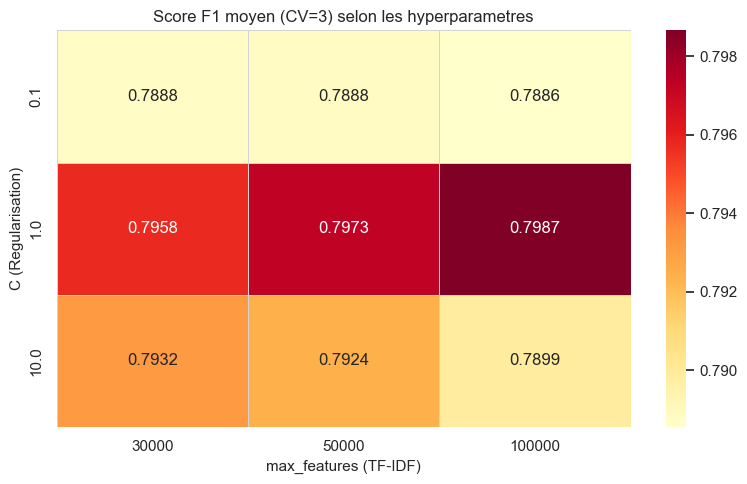


Meilleure combinaison : {'clf__C': 1, 'tfidf__max_features': 100000}
Score F1 CV correspondant : 0.7987


In [7]:
cv_results = pd.DataFrame(grid.cv_results_)

pivot = cv_results.pivot_table(
    values="mean_test_score",
    index="param_clf__C",
    columns="param_tfidf__max_features",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    linecolor="lightgrey",
)
ax.set_xlabel("max_features (TF-IDF)", fontsize=11)
ax.set_ylabel("C (Régularisation)", fontsize=11)
ax.set_title("Score F1 moyen (CV=3) selon les hyperparamètres", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nMeilleure combinaison : {grid.best_params_}")
print(f"Score F1 CV correspondant : {grid.best_score_:.4f}")

## 6. Conclusion

Baseline établie pour la classification de sentiment :

- **Approche** : TF-IDF (bigrammes) + Régression Logistique, optimisé par GridSearchCV.
- **Suivi** : expérience loggée dans MLFlow sous `classique` (paramètres, métriques, matrice de confusion, modèle sérialisé).
- **Enregistrement** : meilleur modèle dans le MLFlow Model Registry sous `logistic_regression`.

**Limites :**
- TF-IDF ne capture pas l'ordre des mots ni le contexte sémantique global.
- Régression Logistique = modèle linéaire, pas de relations non linéaires complexes.

**Suite :** modèles deep learning (LSTM, Transformers) pour mieux capturer la sémantique contextuelle.